In [1]:
import os
import glob
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, pointbiserialr
from scipy.stats import f_oneway, kruskal

import stackview
from PIL import Image
from sklearn.metrics import r2_score, roc_curve, auc

from zod import ZodFrames
from zod.constants import AnnotationProject, Camera
from zod.visualization.object_visualization import overlay_object_2d_box_on_image
from zod.anno.object import Box2D

plt.style.use('default')
sns.set_palette("husl")
SEED = 43
np.random.seed(SEED)

# Load Data

In [25]:
model = "faster-rcnn"

In [13]:
base_data_path_file = f"{model}_metafeatures.csv"

iou_assessor_results = pd.read_csv("../results/assessors/iou_test_ass_" + base_data_path_file, index_col=0)
lrp_assessor_results = pd.read_csv("../results/assessors/lrp_test_ass_" + base_data_path_file, index_col=0)

print(iou_assessor_results.head(5))


   country time_of_day        lat       long road_type road_condition  \
1       PL         day  52.249511  21.043137      city         normal   
6       PL         day  52.239332  21.030383      city         normal   
39      PL         day  52.234241  21.003985      city         normal   
49      PL         day  52.224666  21.071192      city         normal   
67      PL         day  52.234931  21.007292      city         normal   

              weather  solar_angle_elevation  month  hour  ...  mean_conf  \
1   partly-cloudy-day              51.723833      4    10  ...   0.780751   
6           clear-day              42.398401      4     8  ...   0.872886   
39          clear-day              41.490165      4     8  ...   0.851765   
49  partly-cloudy-day              51.883848      4    10  ...   0.716532   
67          clear-day              41.666147      4     8  ...   0.818420   

    std_conf        GT  baseline        lr        dt        rf       mlp  \
1   0.177315  0.327518

In [4]:
dataset_root = "../data/zod"
version = "full" 
zod_frames = ZodFrames(dataset_root=dataset_root, version=version)

Loading infos: 0it [00:00, ?it/s]

In [14]:
with open(f"../results/{model}/predictions.json", "r") as f:
    preds = json.load(f)

# Assessor Performance

In [15]:
def evaluate_regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    errors = y_true - y_pred

    bin_size = 0.1
    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=False)

    ece = 0.0
    N = len(y_pred)

    for i in range(1, len(bins)):
        mask = bin_ids == i
        if not np.any(mask):
            continue

        bin_center = (bins[i - 1] + bins[i]) / 2.0
        median_obs = np.median(y_true[mask])
        ece += (mask.sum() / N) * abs(median_obs - bin_center)
        
    return {
        'r2': r2_score(y_true, y_pred),
        'mae': float(np.mean(np.abs(errors))),
        'mse': float(np.mean(errors ** 2)),
        "p95": np.quantile(np.abs(errors), 0.95),
        'ece': float(ece),              # Expected calibration error
    }


def record_regression_results(results, target, model_name, y_true, y_pred, split='test'):
    metrics = evaluate_regression_metrics(y_true, y_pred)
    split_label = split.capitalize()
    print(f"{split_label} R2 score {metrics['r2']:.4f}")
    print(f"{split_label} MAE score {metrics['mae']:.4f}")
    print(f"{split_label} MSE score {metrics['mse']:.4f}")
    print(f"{split_label} P95 score {metrics['p95']:.4f}")
    print(f"{split_label} ECE score {metrics['ece']:.4f}")
    results.append({
        'target': target,
        'model': model_name,
        f'{split}_r2': metrics['r2'],
        f'{split}_mae': metrics['mae'],
        #f'{split}_mse': metrics['mse'],
        #f'{split}_p95': metrics['p95'],
        f'{split}_ece': metrics['ece'],
    })
    return metrics

## IoU

In [16]:
model_cols = ["baseline", "lr", "dt", "rf", "mlp", "xgb", "autg"]

In [17]:
iou_metrics_rows = []
for m_col in model_cols:
    metrics = evaluate_regression_metrics(iou_assessor_results["GT"], iou_assessor_results[m_col])
    iou_metrics_rows.append({"model": m_col, **metrics})

iou_metrics = pd.DataFrame(iou_metrics_rows).sort_values("r2", ascending=False)
display(iou_metrics)


,model,r2,mae,mse,p95,ece
6,autg,0.458553,0.115261,0.023602,0.314241,0.017815
3,rf,0.442802,0.115969,0.024289,0.320946,0.022857
5,xgb,0.438661,0.116335,0.024469,0.334493,0.020497
1,lr,0.425897,0.120541,0.025026,0.329587,0.031024
2,dt,0.413535,0.119412,0.025565,0.333398,0.035208
4,mlp,0.358230,0.125034,0.027975,0.338278,0.028246
0,baseline,0.285557,0.137267,0.031143,0.377858,0.044890


## LRP

In [ ]:
lrp_metrics_rows = []
for m_col in model_cols:
    metrics = evaluate_regression_metrics(lrp_assessor_results["GT"], lrp_assessor_results[m_col])
    lrp_metrics_rows.append({"model": m_col, **metrics})

lrp_metrics = pd.DataFrame(lrp_metrics_rows).sort_values("r2", ascending=False)
display(lrp_metrics)


,model,r2,mae,mse,p95,ece
6,autg,0.493681,0.095452,0.017473,0.282867,0.015702
3,rf,0.476625,0.097249,0.018062,0.286793,0.017530
5,xgb,0.471797,0.097596,0.018229,0.289813,0.016383
2,dt,0.452023,0.099252,0.018911,0.293928,0.015495
1,lr,0.435118,0.104072,0.019494,0.302289,0.022860
4,mlp,0.391628,0.105271,0.020995,0.305935,0.021135
0,baseline,0.284604,0.119049,0.024689,0.330074,0.043032


# Error analysis

In [19]:
THRESHOLD = 0.5   # Delta between predicte and expected value
TARGET_MODEL = "autg"

## IoU

In [20]:

error_df = iou_assessor_results.copy()
error_df[f"abs_delta_{TARGET_MODEL}"] = (error_df["GT"] - error_df[TARGET_MODEL]).abs()
error_df[f"delta_{TARGET_MODEL}"] = (error_df["GT"] - error_df[TARGET_MODEL])
high_error = error_df[error_df[f"abs_delta_{TARGET_MODEL}"] > THRESHOLD]

print(f"High-error instances (|GT - {TARGET_MODEL}| > {THRESHOLD}): {len(high_error)}")
display(high_error[["GT", TARGET_MODEL, f"abs_delta_{TARGET_MODEL}", f"delta_{TARGET_MODEL}"]].head(10))

High-error instances (|GT - autg| > 0.5): 25


,GT,autg,abs_delta_autg,delta_autg
17132,0.000000,0.517912,0.517912,-0.517912
28188,0.797650,0.283174,0.514475,0.514475
38276,0.796365,0.288978,0.507386,0.507386
38761,0.744539,0.198944,0.545596,0.545596
42124,0.840300,0.306621,0.533679,0.533679
43600,0.913808,0.388245,0.525564,0.525564
44502,0.843029,0.341125,0.501904,0.501904
48018,0.808818,0.207629,0.601189,0.601189
57261,0.683183,0.178109,0.505074,0.505074
57815,0.882536,0.303445,0.579091,0.579091


In [12]:
imgs_good_gt = []
id_good_gt = []
imgs_bad_gt = []
id_bad_gt = []
missing = []
for frame_id in high_error.index:
    zod_frame = zod_frames[frame_id]
    image = zod_frame.get_image() 
    annotations = zod_frame.get_annotation(AnnotationProject.OBJECT_DETECTION)
    annotations_2d = [annotation.box2d for annotation in annotations if annotation.name in ['Vehicle', 'Pedestrian', 'VulnerableVehicle'] and str(annotation.occlusion_level) in ["None", "Medium"] and (annotation.box2d.ymax - annotation.box2d.ymin) >= 25]

    for ann in annotations_2d:
        image_with_boxes = overlay_object_2d_box_on_image(image,ann, color=(0, 255, 0), line_thickness=10)

    pred = preds.get(str(frame_id), {"boxes": []})
    for i, box in enumerate(pred["boxes"]):
        if box == []:
            print(f"Missing box for frame {frame_id}, box index {i}")
        box2d = Box2D(xyxy=np.asarray(box), frame=zod_frame)
        image_with_boxes = overlay_object_2d_box_on_image(image_with_boxes, box2d, color=(255, 0, 0), line_thickness=5)


    if image_with_boxes is None:
        missing.append(frame_id)

    if high_error.loc[frame_id][f"delta_{TARGET_MODEL}"] > 0:
        imgs_good_gt.append(image_with_boxes)
        id_good_gt.append(frame_id)
    else: 
        imgs_bad_gt.append(image_with_boxes)
        id_bad_gt.append(frame_id)

In [13]:
print(f"Number of images: {len(imgs_good_gt) + len(imgs_bad_gt)} with id {high_error.index}")
print(f"Missing images: {len(missing)} with ids: {sorted(missing)}")

Number of images: 25 with id Index([17132, 28188, 38276, 38761, 42124, 43600, 44502, 48018, 57261, 57815,
       58673, 62041, 62118, 65774, 75999, 79368, 80215, 81513, 83036, 86234,
       86913, 87727, 92181, 97338, 98787],
      dtype='int64')
Missing images: 0 with ids: []


High IoU, but assessor predicts low IoU

In [14]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_good_gt], imgs_good_gt))
stackview.switch(stack)

In [15]:
display(iou_assessor_results.loc[id_good_gt])

,country,time_of_day,lat,long,road_type,road_condition,weather,solar_angle_elevation,month,hour,...,mean_conf,std_conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
28188,SE,day,55.595729,12.968518,city,normal,partly-cloudy-day,21.093388,5,16,...,0.723236,0.239027,0.797650,0.311036,0.258107,0.310892,0.275902,0.323814,0.289076,0.283174
38276,PL,night,54.381892,18.615850,city,wet,clear-night,-7.878422,6,20,...,0.800257,0.171310,0.796365,0.371665,0.364652,0.301085,0.284477,0.342217,0.291693,0.288978
38761,SE,day,59.269355,15.240764,city,normal,cloudy,7.421689,5,18,...,0.556117,0.000000,0.744539,0.179486,0.265768,0.317444,0.275523,0.156980,0.190256,0.198944
42124,DE,night,50.108030,8.643605,city,normal,partly-cloudy-night,-31.341675,10,19,...,0.882169,0.000000,0.840300,0.436143,0.373666,0.429547,0.348452,0.313823,0.357534,0.306621
43600,PL,night,54.382469,18.615574,city,normal,clear-night,-7.878422,6,20,...,0.996683,0.000000,0.913808,0.526284,0.511004,0.553332,0.511014,0.359477,0.374981,0.388245
44502,DE,night,50.109216,8.643583,city,normal,partly-cloudy-night,-31.341675,10,19,...,0.945531,0.000000,0.843029,0.486020,0.413107,0.429547,0.378552,0.344020,0.488447,0.341125
48018,DE,day,50.936323,6.963787,city,normal,partly-cloudy-day,15.740325,11,9,...,0.686093,0.169212,0.808818,0.281799,0.188934,0.252665,0.217502,0.136362,0.200679,0.207629
57261,LU,day,49.677938,6.396256,highway,normal,clear-day,8.290657,3,16,...,0.501986,0.000000,0.683183,0.136876,0.243452,0.009359,0.027309,0.141666,0.221321,0.178109
57815,LU,day,49.664392,6.361041,highway,normal,clear-day,8.145341,3,16,...,0.722712,0.100576,0.882536,0.310624,0.394877,0.317444,0.303383,0.257798,0.298371,0.303445
58673,IT,night,41.912808,12.385102,smaller-rural,normal,clear-night,-20.458891,8,20,...,0.736301,0.000000,0.913831,0.321321,0.560034,0.317444,0.361772,0.400207,0.360248,0.397026


IoU low, but assessor predicts high

In [16]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_bad_gt], imgs_bad_gt))
stackview.switch(stack)

In [17]:
display(iou_assessor_results.loc[id_bad_gt])

,country,time_of_day,lat,long,road_type,road_condition,weather,solar_angle_elevation,month,hour,...,mean_conf,std_conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
17132,SE,day,55.600566,12.998065,city,normal,partly-cloudy-day,20.381866,5,16,...,0.998939,0.000884,0.000000,0.528060,0.519435,0.553332,0.563293,0.558749,0.591852,0.517912
65774,SE,day,62.422279,17.187585,arterial-rural,snow,partly-cloudy-night,1.062632,2,14,...,0.994793,0.000000,0.221636,0.524797,0.627974,0.815033,0.748907,0.707467,0.756151,0.740218
86234,IT,night,41.797536,12.535831,highway,normal,clear-night,-19.960883,8,20,...,0.998196,0.000000,0.047155,0.527476,0.671880,0.688123,0.730525,0.795657,0.640344,0.754305
86913,SE,day,63.699394,20.035110,arterial-rural,wet,snow,8.480371,3,15,...,0.998652,0.000000,0.230823,0.527834,0.746300,0.815033,0.839857,0.764296,0.864910,0.821262
98787,SE,night,61.641086,14.920854,smaller-rural,snow,partly-cloudy-night,-6.272593,1,15,...,0.987690,0.000000,0.099112,0.519206,0.576239,0.815033,0.655165,0.821977,0.690169,0.657661


## LRP

In [24]:
lrp_error_df = lrp_assessor_results.copy()
lrp_error_df[f"abs_delta_{TARGET_MODEL}"] = (lrp_error_df["GT"] - lrp_error_df[TARGET_MODEL]).abs()
lrp_error_df[f"delta_{TARGET_MODEL}"] = (lrp_error_df["GT"] - lrp_error_df[TARGET_MODEL])
lrp_high_error = lrp_error_df[lrp_error_df[f"abs_delta_{TARGET_MODEL}"] > THRESHOLD]

print(f"High-error instances (|GT - {TARGET_MODEL}| > {THRESHOLD}): {len(lrp_high_error)}")
display(lrp_high_error[["GT", TARGET_MODEL, f"abs_delta_{TARGET_MODEL}", f"delta_{TARGET_MODEL}"]].head(10))

High-error instances (|GT - autg| > 0.5): 16


,GT,autg,abs_delta_autg,delta_autg
17132,0.000000,0.585432,0.585432,-0.585432
57815,0.765072,0.194845,0.570227,0.570227
58673,0.827662,0.181953,0.645708,0.645708
62118,0.940105,0.313351,0.626754,0.626754
75747,0.650949,0.133561,0.517388,0.517388
75999,0.713886,0.131887,0.581999,0.581999
79368,0.791158,0.155923,0.635235,0.635235
80215,0.627669,0.075903,0.551765,0.551765
81513,0.913053,0.362553,0.550500,0.550500
82549,0.799984,0.287428,0.512556,0.512556


In [25]:
imgs_good_gt_lrp = []
id_good_gt_lrp = []
imgs_bad_gt_lrp = []
id_bad_gt_lrp = []
missing_lrp = []
for frame_id in lrp_high_error.index:
    zod_frame = zod_frames[frame_id]
    image = zod_frame.get_image() 
    annotations = zod_frame.get_annotation(AnnotationProject.OBJECT_DETECTION)
    annotations_2d = [annotation.box2d for annotation in annotations if annotation.name in ['Vehicle', 'Pedestrian', 'VulnerableVehicle'] and str(annotation.occlusion_level) in ["None", "Medium"] and (annotation.box2d.ymax - annotation.box2d.ymin) >= 25]

    for ann in annotations_2d:
        image_with_boxes = overlay_object_2d_box_on_image(image,ann, color=(0, 255, 0), line_thickness=10)

    pred = preds.get(str(frame_id), {"boxes": []})
    for i, box in enumerate(pred["boxes"]):
        if box == []:
            print(f"Missing box for frame {frame_id}, box index {i}")
        box2d = Box2D(xyxy=np.asarray(box), frame=zod_frame)
        image_with_boxes = overlay_object_2d_box_on_image(image_with_boxes, box2d, color=(255, 0, 0), line_thickness=5)


    if image_with_boxes is None:
        missing_lrp.append(frame_id)

    if lrp_high_error.loc[frame_id][f"delta_{TARGET_MODEL}"] > 0:
        imgs_good_gt_lrp.append(image_with_boxes)
        id_good_gt_lrp.append(frame_id)
    else: 
        imgs_bad_gt_lrp.append(image_with_boxes)
        id_bad_gt_lrp.append(frame_id)

In [38]:
print(f"Number of images: {len(imgs_good_gt_lrp) + len(imgs_bad_gt_lrp)} with id {high_error.index}")
print(f"Missing images: {len(missing_lrp)} with ids: {sorted(missing_lrp)}")

Number of images: 16 with id Index([17132, 28188, 38276, 38761, 42124, 43600, 44502, 48018, 57261, 57815,
       58673, 62041, 62118, 65774, 75999, 79368, 80215, 81513, 83036, 86234,
       86913, 87727, 92181, 97338, 98787],
      dtype='int64')
Missing images: 0 with ids: []


In [33]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_good_gt_lrp], imgs_good_gt_lrp))
stackview.switch(stack)

In [34]:
display(lrp_assessor_results.loc[id_good_gt_lrp])

,country,time_of_day,lat,long,road_type,road_condition,weather,solar_angle_elevation,month,hour,...,mean_conf,std_conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
57815,LU,day,49.664392,6.361041,highway,normal,clear-day,8.145341,3,16,...,0.722712,0.100576,0.765072,0.229097,0.312694,0.199488,0.201746,0.146539,0.209688,0.194845
58673,IT,night,41.912808,12.385102,smaller-rural,normal,clear-night,-20.458891,8,20,...,0.736301,0.000000,0.827662,0.238686,0.441706,0.199488,0.180017,0.230905,0.196900,0.181953
62118,DE,day,51.471880,6.992394,arterial-urban,wet,cloudy,8.453200,11,7,...,0.970047,0.000000,0.940105,0.403635,0.414728,0.271117,0.277010,0.593742,0.349126,0.313351
75747,IT,night,41.808514,12.566134,highway,normal,clear-night,-28.310652,8,21,...,0.680016,0.000000,0.650949,0.198967,0.365229,0.199488,0.193486,0.169049,0.192160,0.133561
75999,PL,day,52.199339,21.769838,highway,normal,snow,47.038541,4,10,...,0.653217,0.085637,0.713886,0.180056,0.221073,0.199488,0.178662,0.145968,0.201368,0.131887
79368,FR,day,45.773439,4.827209,arterial-urban,normal,partly-cloudy-day,29.433937,2,13,...,0.770220,0.000000,0.791158,0.262622,0.300851,0.182331,0.176611,0.092903,0.168091,0.155923
80215,SE,day,64.059508,20.852945,smaller-rural,snow,partly-cloudy-day,23.792037,3,10,...,0.544165,0.000000,0.627669,0.103100,0.223511,0.091176,0.144631,-0.078578,0.057790,0.075903
81513,DE,night,51.449620,7.758618,arterial-urban,wet,cloudy,-22.178715,12,17,...,0.997377,0.000000,0.913053,0.422921,0.389019,0.487909,0.484074,0.525230,0.394635,0.362553
82549,FR,day,43.632538,3.922079,smaller-rural,normal,clear-day,42.502973,3,10,...,0.855373,0.000000,0.799984,0.322712,0.388487,0.235807,0.242389,0.151297,0.304468,0.287428
83077,FR,day,43.732490,7.293734,highway,normal,clear-day,17.323803,2,7,...,0.791193,0.000000,0.726518,0.277422,0.373207,0.182331,0.199802,0.061661,0.202347,0.222310


In [35]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_bad_gt_lrp], imgs_bad_gt_lrp))
stackview.switch(stack)

In [36]:
display(lrp_assessor_results.loc[id_bad_gt_lrp])

,country,time_of_day,lat,long,road_type,road_condition,weather,solar_angle_elevation,month,hour,...,mean_conf,std_conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
17132,SE,day,55.600566,12.998065,city,normal,partly-cloudy-day,20.381866,5,16,...,0.998939,0.000884,0.000000,0.424023,0.437671,0.487909,0.488086,0.479972,0.518777,0.585432
86234,IT,night,41.797536,12.535831,highway,normal,clear-night,-19.960883,8,20,...,0.998196,0.000000,0.044310,0.423499,0.536328,0.619697,0.652205,0.697005,0.679511,0.673194
86913,SE,day,63.699394,20.035110,arterial-rural,wet,snow,8.480371,3,15,...,0.998652,0.000000,0.211646,0.423821,0.602932,0.748682,0.752174,0.781405,0.770805,0.771620


## Same Errors?

In [21]:
common_good_ids = set(id_good_gt).intersection(set(id_good_gt_lrp))
total_good_gt = len(set(id_good_gt).union(set(id_good_gt_lrp)))
not_common_good_ids = set(id_good_gt).symmetric_difference(set(id_good_gt_lrp))
print(f"Common good GT high-error IDs between IOU and LRP assessors: {common_good_ids}, in percentage: {len(common_good_ids)/total_good_gt*100:.2f}%")
print(f"IDS not common in good GT high-error: {not_common_good_ids} \n")

common_wrong_ids = set(id_bad_gt).intersection(set(id_bad_gt_lrp))
total_wrong_gt = len(set(id_bad_gt).union(set(id_bad_gt_lrp)))
not_common_wrong_ids = set(id_bad_gt).symmetric_difference(set(id_bad_gt_lrp))
print(f"Common wrong GT high-error IDs between IOU and LRP assessors: {common_wrong_ids}, in percentage: {len(common_wrong_ids)/total_wrong_gt*100:.2f}%")
print(f"IDS not common in wrong GT high-error: {not_common_wrong_ids}")

NameError: name 'id_good_gt' is not defined

# Regression Reliability Plots

Calibration curves but for regression. 

In [22]:
def plot_calibration_curve(y_true, y_pred, bin_size=0.1, metric: str = "IoU", ax=None, label=None, iden_line: bool = True):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=False)

    avg_predicted = []
    avg_observed = []
    err_low = []
    err_high = []
    rng = np.random.default_rng(0)
    alpha = (1.0 - 0.95) / 2.0    #95% CI

    for i in range(1, len(bins)):
        mask = bin_ids == i
        if not np.any(mask):
            continue
        avg_predicted.append((bins[i - 1] + bins[i]) / 2)  # Center of bin, so it is not influenced by the data
        avg_observed.append(float(np.median(y_true[mask])))   # Mean of observed IoU

        if 300 > 0: #Bootstrap CI
            boots = np.empty(300)
            n = y_true[mask].size
            for b in range(300):
                boots[b] = np.median(rng.choice(y_true[mask], size=n, replace=True))
            lo = np.quantile(boots, alpha)
            hi = np.quantile(boots, 1.0 - alpha)
            #err_low.append(float(np.median(y_true[mask])) - lo)
            err_low.append(lo)
            #err_high.append(hi - float(np.median(y_true[mask])))
            err_high.append(hi)
        else:
            err_low.append(np.nan)
            err_high.append(np.nan)
    
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    if iden_line:
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Perfect')
    ax.plot(avg_predicted, avg_observed, marker='o', label=label or 'Model')
    ax.fill_between(avg_predicted, err_low, err_high, alpha=0.15)
    #ax.errorbar(avg_predicted,avg_observed,yerr=np.vstack([err_low, err_high]),fmt='o-',capsize=3,label=label or 'Model')
    ax.set_xlabel(f'Predicted {metric} (bin center)')
    ax.set_ylabel(f'Observed {metric} (median)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=':', alpha=0.6)
    if label is not None:
        ax.legend()
    return ax


def plot_inst_per_bin(y_pred, bin_size=0.1, ax=None, label=None, alpha=1.0, linestyle='-', fill="///", fillcolor="black"):
    y_pred = np.asarray(y_pred)
    
    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=False)

    n_instances = []
    bin_centers = [] 
    for i in range(1, len(bins)):
        mask = bin_ids == i
        n = np.count_nonzero(mask)
        n_instances.append(n)
        bin_centers.append((bins[i - 1] + bins[i]) / 2)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    ax.bar(bin_centers, height=n_instances, width=bin_size, label=label or 'Model', alpha=alpha, linestyle=linestyle, hatch=fill, edgecolor='black', color=fillcolor)
    ax.set_xlabel('Bins')
    ax.set_ylabel('Nº of instances')
    if label is not None:
        ax.legend()
    return ax

## IoU

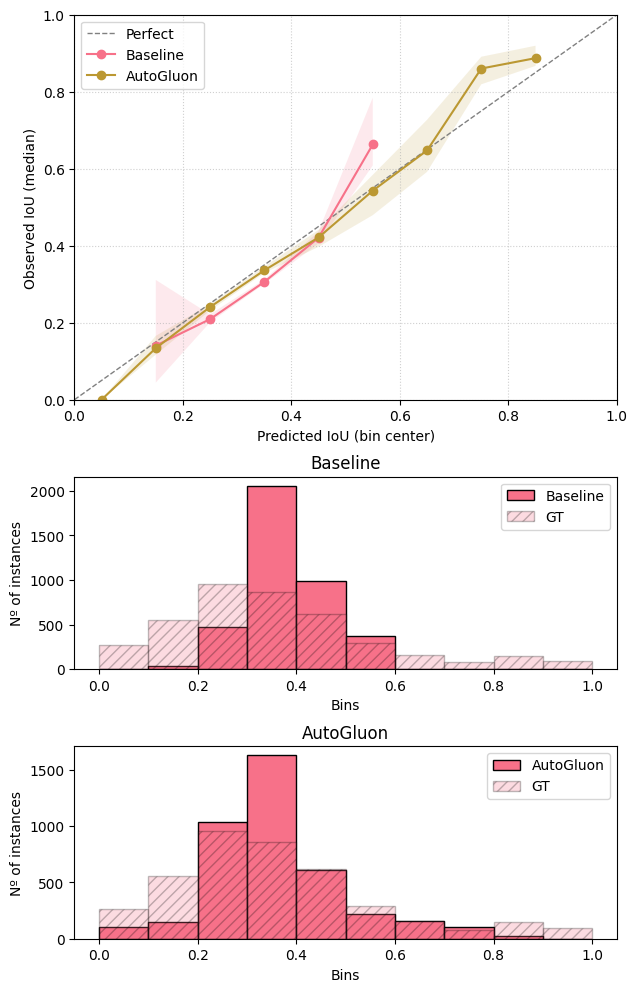

In [36]:
fig = plt.figure(figsize=(7, 12))
gs = GridSpec(3, 1, height_ratios=[2, 1, 1], hspace=0.3, wspace=0.1)
ax_cal = fig.add_subplot(gs[0, :])

plot_calibration_curve(iou_assessor_results["GT"],iou_assessor_results["baseline"],ax=ax_cal,label="Baseline")
plot_calibration_curve(iou_assessor_results["GT"],iou_assessor_results["autg"],ax=ax_cal,label="AutoGluon", iden_line=False)
ax_cal.legend()

ax_baseline = fig.add_subplot(gs[1, 0])
plot_inst_per_bin(iou_assessor_results["baseline"], ax=ax_baseline, label="Baseline", fillcolor="C0", fill=None)
plot_inst_per_bin(iou_assessor_results["GT"], ax=ax_baseline,alpha=0.25, label="GT", fillcolor="C0", fill="///")
ax_baseline.set_title("Baseline")
ax_rf = fig.add_subplot(gs[2, 0])
plot_inst_per_bin(iou_assessor_results["autg"], ax=ax_rf, label="AutoGluon", fillcolor="C0", fill=None)
plot_inst_per_bin(iou_assessor_results["GT"], ax=ax_rf, alpha=0.25,label="GT", fillcolor="C0", fill="///")
ax_rf.set_title("AutoGluon")

plt.savefig(f"./plots/{model}_iou_baseline_vs_autog_calib_curve.svg", dpi=200, bbox_inches='tight')
plt.show()

## LRP

/tmp/ipykernel_60310/129512201.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


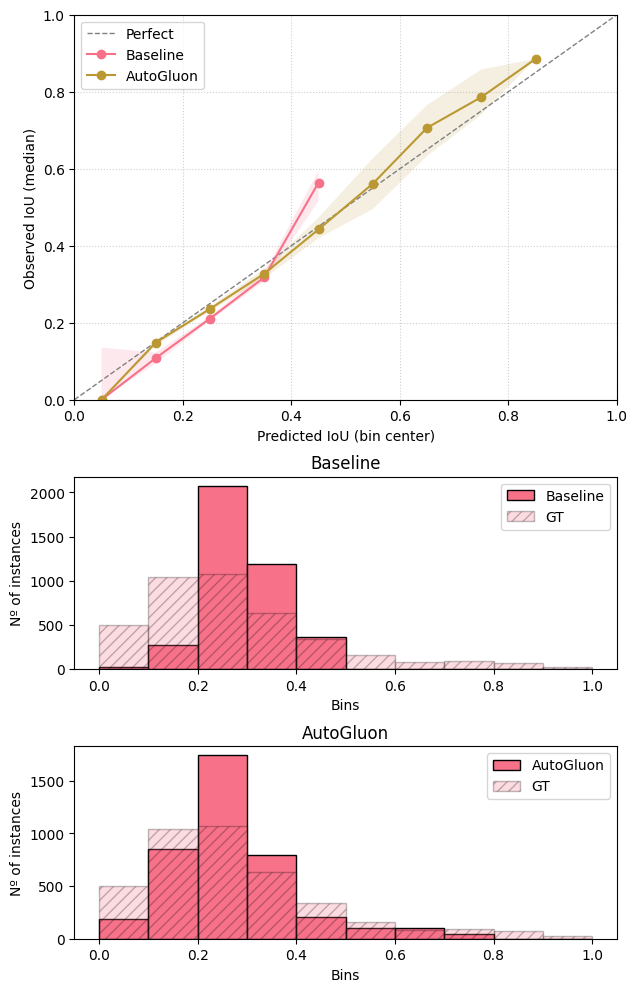

In [37]:

fig = plt.figure(figsize=(7, 12))
gs = GridSpec(3, 1, height_ratios=[2, 1, 1], hspace=0.3, wspace=0.1)
ax_cal = fig.add_subplot(gs[0, :])

plot_calibration_curve(lrp_assessor_results["GT"],lrp_assessor_results["baseline"],ax=ax_cal,label="Baseline")
plot_calibration_curve(lrp_assessor_results["GT"],lrp_assessor_results["autg"],ax=ax_cal,label="AutoGluon", iden_line=False)
ax_cal.legend()

ax_baseline = fig.add_subplot(gs[1, 0])
plot_inst_per_bin(lrp_assessor_results["baseline"], ax=ax_baseline, label="Baseline", fillcolor="C0", fill=None)
plot_inst_per_bin(lrp_assessor_results["GT"], ax=ax_baseline, label="GT", alpha=0.25, fillcolor="C0", fill="///")
ax_baseline.set_title("Baseline")
ax_autg = fig.add_subplot(gs[2, 0])
plot_inst_per_bin(lrp_assessor_results["autg"], ax=ax_autg, label="AutoGluon", fillcolor="C0", fill=None)
plot_inst_per_bin(lrp_assessor_results["GT"], ax=ax_autg, label="GT", alpha=0.25, fillcolor="C0", fill="///")
ax_autg.set_title("AutoGluon")

plt.tight_layout()
plt.savefig(f"./plots/{model}_lrp_baseline_vs_autog_calib_curve.svg", dpi=200, bbox_inches='tight')
plt.show()

# AUROC

For the AUROC we need to discretize the task to binary by setting a treshold. This is not ideal as we are deleting information. So not very useful. 

In [22]:
def plot_auroc(y_true_iou, y_pred, threshold=0.5, ax=None, label=None):
    y_true_iou = np.asarray(y_true_iou)
    y_pred = np.asarray(y_pred)
    success = (y_true_iou > threshold).astype(int)

    fpr, tpr, _ = roc_curve(success, y_pred)
    roc_auc = auc(fpr, tpr)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Random')
    ax.plot(fpr, tpr, label=label or f'AUROC = {roc_auc:.3f}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    return ax, roc_auc

## IoU

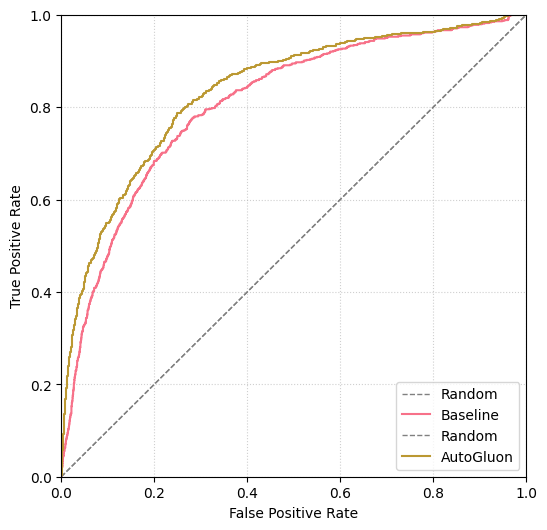

In [74]:
fig, ax = plt.subplots(figsize=(6, 6))
_, roc_auc = plot_auroc(iou_assessor_results["GT"], iou_assessor_results["baseline"], threshold=0.5, ax=ax, label="Baseline")
_, roc_auc = plot_auroc(iou_assessor_results["GT"], iou_assessor_results["autg"], threshold=0.5, ax=ax, label="AutoGluon")
ax.legend()